<a href="https://colab.research.google.com/github/ShaojieDong503/HAD5015-Project/blob/main/SatPM25_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install rasterio geopandas pyproj shapely fiona

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
MONTHLY_ZIP = "/content/drive/MyDrive/Thesis-Shaojie Dong/AOD Data/Monthly.zip"
OUT_DIR = "/content/drive/MyDrive/Thesis-Shaojie Dong/AOD Data/ontario_npz"

In [ ]:
import os
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# Approximate Ontario bounding box in EPSG:4326 (lon/lat)
ONTARIO_BBOX_WGS84 = (-95.16, 41.67, -74.34, 56.86)  # (minx, miny, maxx, maxy)

In [ ]:
import re

def extract_year_from_name(name):
    """
    Extract year from pattern like:
    V5NA05.HybridPM25.NorthAmerica.2010-2010-DEC.zip
    """
    m = re.search(r"\.(\d{4})-\d{4}-", name)
    if m:
        return int(m.group(1))
    return None

In [ ]:
import io
import zipfile
import tempfile
import shutil
import numpy as np
import rasterio
from rasterio.mask import mask
from pyproj import CRS, Transformer


def bbox_polygon_wgs84(bbox):
    minx, miny, maxx, maxy = bbox
    return {
        "type": "Polygon",
        "coordinates": [[
            [minx, miny], [maxx, miny], [maxx, maxy], [minx, maxy], [minx, miny]
        ]]
    }

def reproject_polygon(geom, src_crs, dst_crs):
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)

    def reproj_ring(ring):
        out = []
        for x, y in ring:
            X, Y = transformer.transform(x, y)
            out.append([X, Y])
        return out

    if geom["type"] != "Polygon":
        raise ValueError("Expected Polygon.")
    return {"type": "Polygon", "coordinates": [reproj_ring(r) for r in geom["coordinates"]]}

def find_df1_dir(root):
    for r, d, f in os.walk(root):
        if os.path.basename(r) == "DF1":
            return r
    return None

def read_prj_crs(prj_path):
    if prj_path is None:
        return None
    with open(prj_path, "r") as f:
        wkt = f.read().strip()
    try:
        return CRS.from_wkt(wkt)
    except Exception:
        return None

def clip_save_npz(asc_path, prj_crs, out_dir, bbox_wgs84):
    with rasterio.open(asc_path) as src:
        src_crs = src.crs
        if src_crs is None and prj_crs is not None:
            src_crs = prj_crs

        if src_crs is None:
            raise ValueError(f"CRS unknown for {asc_path} (no usable .prj).")

        ont_geom = bbox_polygon_wgs84(bbox_wgs84)

        # Reproject Ontario bbox polygon into raster CRS
        if src_crs.to_epsg() != 4326:
            geom_in_src = reproject_polygon(ont_geom, CRS.from_epsg(4326), src_crs)
        else:
            geom_in_src = ont_geom

        out_img, out_transform = mask(src, [geom_in_src], crop=True, nodata=src.nodata)
        arr = out_img[0].astype(np.float32)

        # Save metadata for ML + later georeferencing
        t = out_transform
        transform_6 = np.array([t.a, t.b, t.c, t.d, t.e, t.f], dtype=np.float64)
        crs_wkt = src_crs.to_wkt()

        base = os.path.splitext(os.path.basename(asc_path))[0]
        out_path = os.path.join(out_dir, f"{base}_ON.npz")

        np.savez_compressed(
            out_path,
            arr=arr,
            transform=transform_6,
            crs_wkt=crs_wkt,
            nodata=src.nodata if src.nodata is not None else np.nan
        )
        return out_path, arr.shape

processed = 0
failed_inner = 0
failed_files = 0

with zipfile.ZipFile(MONTHLY_ZIP, "r") as outer:
    #inner_zips = [n for n in outer.namelist() if n.lower().endswith(".zip")]
    #print("Inner zips found:", len(inner_zips))
    inner_zips_all = [n for n in outer.namelist() if n.lower().endswith(".zip")]

    inner_zips = []
    for n in inner_zips_all:
        yr = extract_year_from_name(n)
        if yr is not None and 2010 <= yr <= 2023:
            inner_zips.append(n)

    print("Inner zips found (2010–2023):", len(inner_zips))

    for inner_name in inner_zips:
        tmpdir = None
        try:
            inner_bytes = outer.read(inner_name)

            tmpdir = tempfile.mkdtemp(prefix="innerzip_")
            inner_path = os.path.join(tmpdir, "inner.zip")
            with open(inner_path, "wb") as f:
                f.write(inner_bytes)

            with zipfile.ZipFile(inner_path, "r") as z:
                z.extractall(tmpdir)

            df1_dir = find_df1_dir(tmpdir)
            if df1_dir is None:
                raise FileNotFoundError("DF1 folder not found.")

            prj_files = [os.path.join(df1_dir, f) for f in os.listdir(df1_dir) if f.lower().endswith(".prj")]
            prj_crs = read_prj_crs(prj_files[0]) if prj_files else None

            asc_files = sorted([os.path.join(df1_dir, f) for f in os.listdir(df1_dir) if f.lower().endswith(".asc")])
            if not asc_files:
                raise FileNotFoundError("No .asc files in DF1.")

            for asc in asc_files:
                try:
                    out_path, shape = clip_save_npz(asc, prj_crs, OUT_DIR, ONTARIO_BBOX_WGS84)
                    processed += 1
                    print(f"[OK] {os.path.basename(asc)} -> {os.path.basename(out_path)}  shape={shape}")
                except Exception as e:
                    failed_files += 1
                    print(f"[FAIL FILE] {os.path.basename(asc)}  reason: {e}")

        except Exception as e:
            failed_inner += 1
            print(f"[FAIL ZIP] {inner_name}  reason: {e}")

        finally:
            if tmpdir:
                shutil.rmtree(tmpdir, ignore_errors=True)

print("Done.")
print("processed files:", processed)
print("failed inner zips:", failed_inner)
print("failed asc files:", failed_files)

Inner zips found (2010–2023): 168
[OK] V5NA05.HybridPM25.NorthAmerica.2010-2010-APR.asc -> V5NA05.HybridPM25.NorthAmerica.2010-2010-APR_ON.npz  shape=(1519, 2082)
[OK] V5NA05.HybridPM25.NorthAmerica.2010-2010-AUG.asc -> V5NA05.HybridPM25.NorthAmerica.2010-2010-AUG_ON.npz  shape=(1519, 2082)
[OK] V5NA05.HybridPM25.NorthAmerica.2010-2010-DEC.asc -> V5NA05.HybridPM25.NorthAmerica.2010-2010-DEC_ON.npz  shape=(1519, 2082)
[OK] V5NA05.HybridPM25.NorthAmerica.2010-2010-FEB.asc -> V5NA05.HybridPM25.NorthAmerica.2010-2010-FEB_ON.npz  shape=(1519, 2082)
[OK] V5NA05.HybridPM25.NorthAmerica.2010-2010-JAN.asc -> V5NA05.HybridPM25.NorthAmerica.2010-2010-JAN_ON.npz  shape=(1519, 2082)
[OK] V5NA05.HybridPM25.NorthAmerica.2010-2010-JUL.asc -> V5NA05.HybridPM25.NorthAmerica.2010-2010-JUL_ON.npz  shape=(1519, 2082)
[OK] V5NA05.HybridPM25.NorthAmerica.2010-2010-JUN.asc -> V5NA05.HybridPM25.NorthAmerica.2010-2010-JUN_ON.npz  shape=(1519, 2082)
[OK] V5NA05.HybridPM25.NorthAmerica.2010-2010-MAR.asc -> V5NA05

In [ ]:
import os
import numpy as np

def check_npz_missing(npz_path):
    data = np.load(npz_path)
    arr = data["arr"]
    nodata = data["nodata"]

    total_pixels = arr.size

    nan_count = np.isnan(arr).sum()

    if not np.isnan(nodata):
        nodata_count = (arr == nodata).sum()
    else:
        nodata_count = 0

    missing_total = nan_count + nodata_count

    nodata_scalar = data["nodata"]

    # convert numpy scalar / 0-d array → Python float
    if isinstance(nodata_scalar, np.ndarray):
        nodata_scalar = nodata_scalar.item()

    return {
        "file": os.path.basename(npz_path),
        "shape": arr.shape,
        "total_pixels": total_pixels,
        "nan_count": int(nan_count),
        "nodata_count": int(nodata_count),
        "missing_total": int(missing_total),
        "missing_percent": float(missing_total / total_pixels * 100),
        "nodata_value": float(nodata_scalar)
        }


results = []
nodata_values = []

for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith(".npz"):
        info = check_npz_missing(os.path.join(OUT_DIR, f))
        results.append(info)
        nodata_values.append(info["nodata_value"])

# Print summary
files_with_missing = [r for r in results if r["missing_total"] > 0]

print("Total files checked:", len(results))
print("Files with missing values:", len(files_with_missing))

for r in files_with_missing[:10]:
    print(r)

# --- NEW PART: check nodata consistency ---
unique_nodata = set(nodata_values)

print("\nUnique nodata values across files:")
print(unique_nodata)

if len(unique_nodata) == 1:
    print("All files share the same nodata value.")
else:
    print("Warning: Multiple nodata values detected.")

Total files checked: 168
Files with missing values: 168
{'file': 'V5NA05.HybridPM25.NorthAmerica.2010-2010-APR_ON.npz', 'shape': (1519, 2082), 'total_pixels': 3162558, 'nan_count': 0, 'nodata_count': 603859, 'missing_total': 603859, 'missing_percent': 19.09400554867294, 'nodata_value': -999.9000244140625}
{'file': 'V5NA05.HybridPM25.NorthAmerica.2010-2010-AUG_ON.npz', 'shape': (1519, 2082), 'total_pixels': 3162558, 'nan_count': 0, 'nodata_count': 603859, 'missing_total': 603859, 'missing_percent': 19.09400554867294, 'nodata_value': -999.9000244140625}
{'file': 'V5NA05.HybridPM25.NorthAmerica.2010-2010-DEC_ON.npz', 'shape': (1519, 2082), 'total_pixels': 3162558, 'nan_count': 0, 'nodata_count': 603859, 'missing_total': 603859, 'missing_percent': 19.09400554867294, 'nodata_value': -999.9000244140625}
{'file': 'V5NA05.HybridPM25.NorthAmerica.2010-2010-FEB_ON.npz', 'shape': (1519, 2082), 'total_pixels': 3162558, 'nan_count': 0, 'nodata_count': 603859, 'missing_total': 603859, 'missing_perce

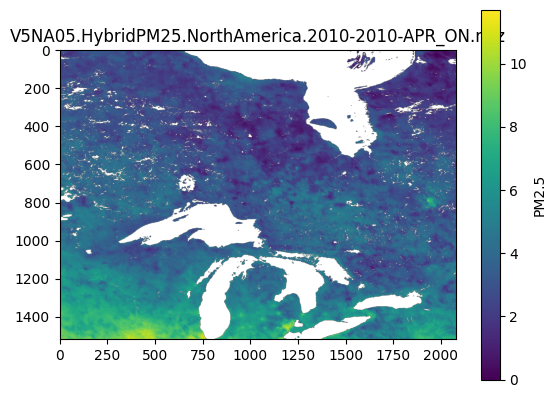

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

fp = os.path.join(OUT_DIR, sorted([f for f in os.listdir(OUT_DIR) if f.endswith(".npz")])[0])

data = np.load(fp)
arr = data["arr"]
nodata = data["nodata"].item() if isinstance(data["nodata"], np.ndarray) else data["nodata"]

# mask nodata
arr_plot = arr.copy()
arr_plot[arr_plot == nodata] = np.nan

plt.figure()
plt.imshow(arr_plot)
plt.title(os.path.basename(fp))
plt.colorbar(label="PM2.5")
plt.show()

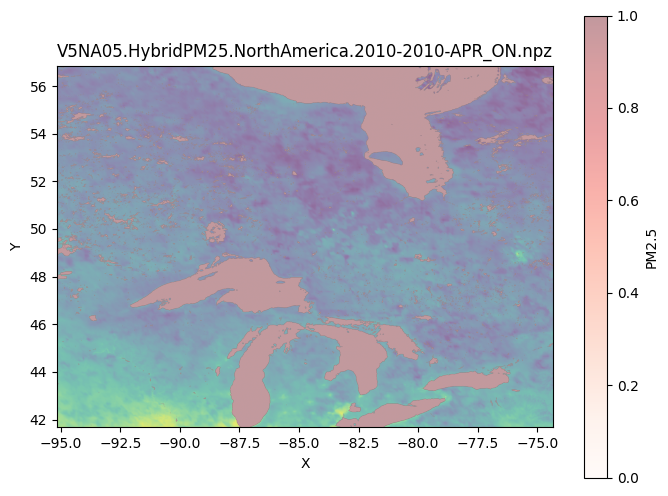

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from rasterio.transform import Affine

# pick one file
fp = os.path.join(OUT_DIR, sorted([f for f in os.listdir(OUT_DIR) if f.endswith(".npz")])[0])

data = np.load(fp)
arr = data["arr"]
transform_vals = data["transform"]
nodata = data["nodata"].item() if isinstance(data["nodata"], np.ndarray) else data["nodata"]

transform = Affine(*transform_vals)

# convert nodata to NaN for plotting
arr_plot = arr.astype(float)
arr_plot[arr_plot == nodata] = np.nan

# compute spatial extent
height, width = arr_plot.shape
left, top = transform * (0, 0)
right, bottom = transform * (width, height)
extent = [left, right, bottom, top]

# missing mask
missing_mask = np.isnan(arr_plot)

plt.figure(figsize=(8, 6))

# plot data
plt.imshow(arr_plot, extent=extent)

# overlay missing pixels in red (semi-transparent)
plt.imshow(missing_mask, extent=extent, cmap="Reds", alpha=0.4)

plt.title(os.path.basename(fp))
plt.colorbar(label="PM2.5")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()